## libraries and File Paths

In [ ]:
import os
import pandas as pd
import numpy as np
import statsmodels.api as sm
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.cm import coolwarm
from matplotlib.colors import Normalize
from matplotlib.colors import TwoSlopeNorm
import matplotlib.colors as colors

In [ ]:
# setting base directory 
dir = "/global/scratch/users/yougsanghvi"


In [ ]:
# Input file paths:
# 1. setting suicide panel file path
suicide_proj_folder = "data"
suicide_panel_folderp = os.path.join("merged", "USA")
suicide_panel_filen = "USA_adm2_1968_2004_monthly.dta"
suicide_panel_filep = os.path.join(dir, suicide_proj_folder, suicide_panel_folderp, suicide_panel_filen)

# 2. Define paths for usa county shapefile
usa_county_dir = os.path.join(dir, "shapefiles")
usa_county_filename = "tl_2016_us_county_mortality.shp"
usa_county_path = os.path.join(usa_county_dir, usa_county_filename)

# 3. Specific folder for attribution results
attribution_output_folderpath = os.path.join(
    dir,
    "gdnat_era5_compare_output"
)

# 4. Define the modeling input filename
attribution_output_filename = "merged_data_panel_extended.csv"

# Construct the full file path for the prev modeling data
attribution_output_filepath = os.path.join(
    attribution_output_folderpath,
    attribution_output_filename
)

# --- Load data ---
attribution_output_data = pd.read_csv(attribution_output_filepath)
suicide_panel_data = pd.read_stata(suicide_panel_filep)
usa_counties = gpd.read_file(usa_county_path)

In [ ]:
# Output file paths 

# path for intermediate outputs 
output_path_intermediate = os.path.join(dir, "gdnat_intermediate_outputs")

In [ ]:
usa_counties.columns

Index(['ID_1', 'ID_2', 'COUNTYNS', 'GEOID', 'NAME', 'NAMELSAD', 'LSAD',
       'CLASSFP', 'MTFCC', 'CSAFP', 'CBSAFP', 'METDIVFP', 'FUNCSTAT', 'ALAND',
       'AWATER', 'INTPTLAT', 'INTPTLON', 'ID_0', 'geometry'],
      dtype='object')

## Data Processing

In [5]:
# Filter and select columns
filtered_suicide = suicide_panel_data[
    (suicide_panel_data["agegroup"] == 0) & (suicide_panel_data["gender"] == 0)
][[
    'fipsst', 'fipscty', 'fips', 'year', 'month', 'num_of_suicide',
    'suiciderate', 'population', 'adm1_id', 'adm2_id',
    'statename', 'countyname'
]]


In [6]:
# Tagging counties with incomplete data 

fips_1979_1988 = set(
    filtered_suicide[
        (filtered_suicide['year'] >= 1979) & 
        (filtered_suicide['year'] <= 1988) &
        (~filtered_suicide['suiciderate'].isna())
    ]['fips'].unique()
)

fips_1989plus = set(
    filtered_suicide[
        (filtered_suicide['year'] >= 1989) &
        (~filtered_suicide['suiciderate'].isna())
    ]['fips'].unique()
)

# Identify categories
fips_all_years = fips_1979_1988 & fips_1989plus
fips_only_early = fips_1979_1988 - fips_1989plus

# Create mapping
def tag_missing(fips_str):
    if pd.isna(fips_str):
        return np.nan
    fips_int = int(fips_str)
    if fips_int in fips_all_years:
        return 0
    elif fips_int in fips_only_early:
        return 1
    else:
        return np.nan

# Apply tag to dataset
filtered_suicide['missing'] = filtered_suicide['fips'].apply(tag_missing)
complete_data_suicide = filtered_suicide[filtered_suicide['missing'] == 0]


In [ ]:
# merging the dataset

# Ensure ID columns are integers
complete_data_suicide['fips'] = complete_data_suicide['fips'].astype(int)
attribution_output_data['poly_id'] = attribution_output_data['poly_id'].astype(int)

# Perform inner merge on year, month, and ID
merged_data = pd.merge(
    complete_data_suicide,
    attribution_output_data,
    how='inner',
    left_on=['year', 'month', 'fips'],
    right_on=['year', 'month', 'poly_id']
)




/tmp/ipykernel_837889/3047664822.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  complete_data_suicide['fips'] = complete_data_suicide['fips'].astype(int)


In [14]:
# Difference between climate and counterfactual models
merged_data['diff_suicide'] = merged_data['y_hat_era5'] - merged_data['y_hat_gdnat']

# Counterfactual suicide rate (removing climate effect)
merged_data['suiciderate_cf'] = merged_data['suiciderate'] - merged_data['diff_suicide']


In [16]:
merged_data.to_csv(os.path.join(output_path_intermediate,"suicide_data_withcf.csv"), index=False)

In [18]:
# Subset
subset = merged_data[(merged_data['year'] >= 2000) & (merged_data['year'] <= 2004)].copy()

# Date and time index
subset['date'] = pd.to_datetime(dict(year=subset['year'], month=subset['month'], day=1))
subset['time_index'] = (subset['date'].dt.year - 2000) * 12 + (subset['date'].dt.month - 1)


In [46]:
# calculating trends and attribution

def get_trend_strict(group):
    if group['suiciderate'].isna().any() or group['suiciderate_cf'].isna().any():
        return pd.Series({'actual_trend': np.nan, 'cf_trend': np.nan})

    X = sm.add_constant(group['time_index'])
    actual_model = sm.OLS(group['suiciderate'], X).fit()
    cf_model = sm.OLS(group['suiciderate_cf'], X).fit()

    return pd.Series({
        'actual_trend': actual_model.params['time_index'],
        'cf_trend': cf_model.params['time_index']
    })

# Apply to each fips group
county_trends = subset.groupby('fips').apply(get_trend_strict).reset_index()

# Attribution percentage
county_trends['pct_attributable_climate'] = (
    (county_trends['actual_trend'] - county_trends['cf_trend']) / county_trends['actual_trend']
) * 100

county_trends['diff_attributable_climate'] = (
    (county_trends['actual_trend'] - county_trends['cf_trend']))


/tmp/ipykernel_837889/2698286987.py:17: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  county_trends = subset.groupby('fips').apply(get_trend_strict).reset_index()


In [47]:
county_trends.to_csv(os.path.join(output_path_intermediate,"trends_withcf.csv"), index=False)

## Plotting the results

In [59]:
# Convert GEOID to integer FIPS code
usa_counties['fips'] = usa_counties['GEOID'].astype(int)

# Rough bounding box for mainland USA (excluding AK, HI, PR, etc.)
# [minx, miny, maxx, maxy] → [lon_min, lat_min, lon_max, lat_max]
bbox = [-125, 24.5, -66.5, 49.5]  # Lower 48 states

# Subset using the bounding box
mainland_usa = usa_counties.cx[bbox[0]:bbox[2], bbox[1]:bbox[3]]

# Merge trends onto shapefile
full_coverage = mainland_usa.merge(county_trends, on='fips', how='left')


In [62]:
def plot_county_map(gdf, column, title, legend_title='', vmin=None, vmax=None, clip_pct=0, cmap='coolwarm'):
    """
    Plot a choropleth map of counties with optional color scale clipping and custom colormap.

    Parameters:
        gdf: GeoDataFrame with geometry and data
        column: Name of the column to plot
        title: Title of the plot
        legend_title: Title for the colorbar
        vmin, vmax: Manual scale limits (optional)
        clip_pct: If > 0, uses symmetric clipping based on percentile (e.g., 5 → 5th/95th percentiles)
        cmap: Colormap name or object (default='coolwarm')
    """

    # Symmetric percentile-based scale clipping if requested
    if clip_pct > 0:
        abs_q = gdf[column].abs().quantile(1 - clip_pct / 100)
        vmin = -abs_q if vmin is None else vmin
        vmax = abs_q if vmax is None else vmax
    elif vmin is None or vmax is None:
        max_abs = np.nanmax(np.abs(gdf[column].dropna()))
        vmin, vmax = -max_abs, max_abs

    fig, ax = plt.subplots(figsize=(12, 8))
    gdf.plot(
        column=column,
        cmap=cmap,
        linewidth=0.1,
        edgecolor='gray',
        legend=True,
        ax=ax,
        vmin=vmin,
        vmax=vmax
    )

    ax.set_title(title, fontsize=14)
    ax.axis('off')
    ax.set_aspect('equal')

    # Add legend label
    cax = ax.get_figure().get_axes()[1]
    cax.set_ylabel(legend_title)

    plt.tight_layout()
    plt.show()


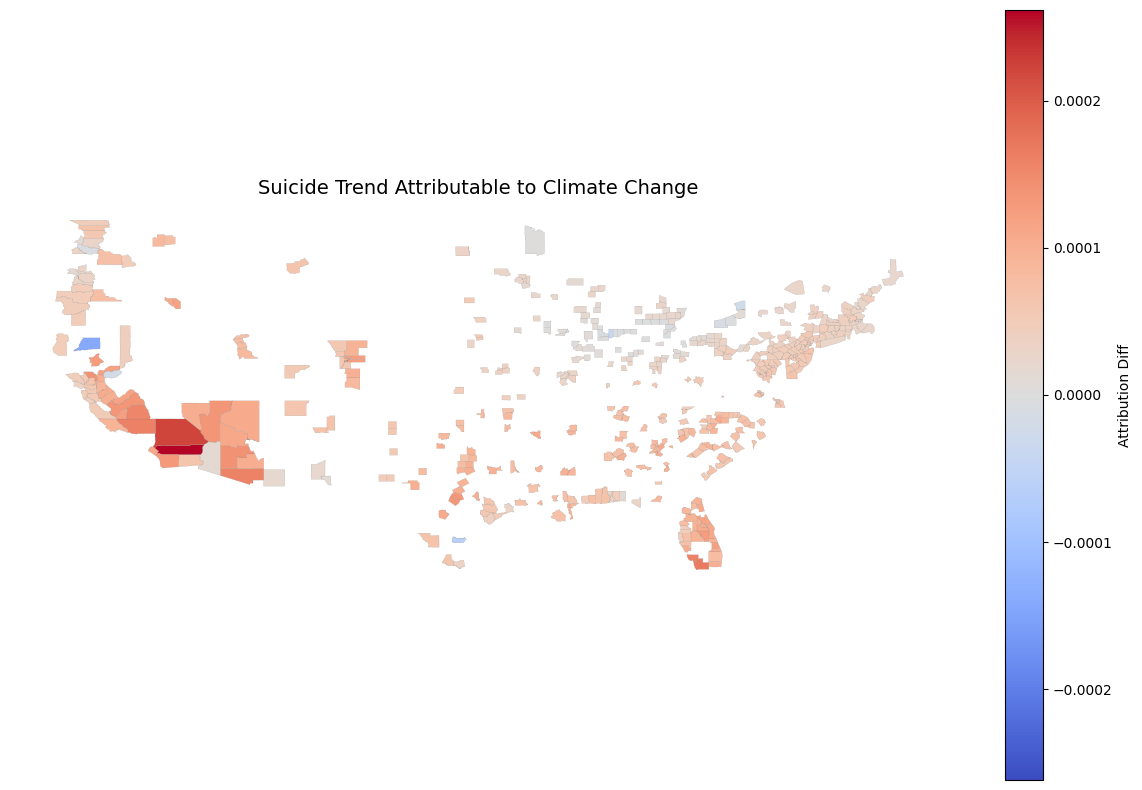

In [63]:
plot_county_map(full_coverage, 'diff_attributable_climate',
                title='Suicide Trend Attributable to Climate Change',
                legend_title='Attribution Diff', cmap='coolwarm')

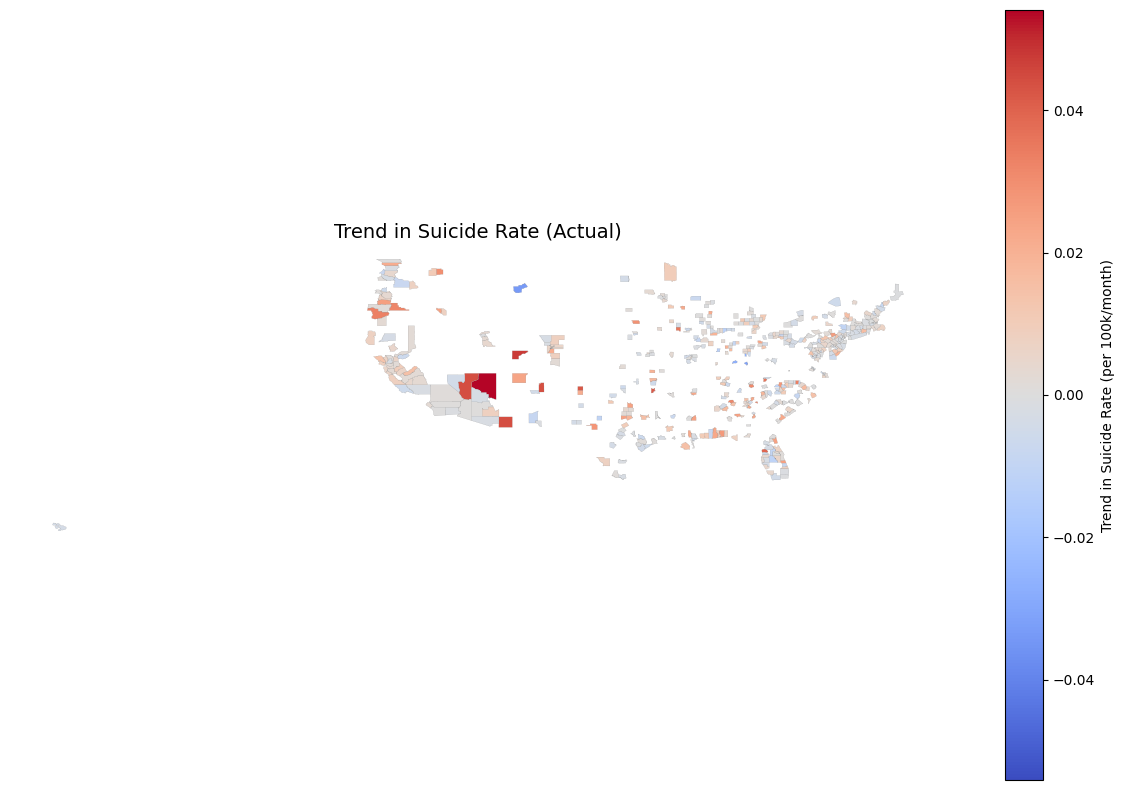

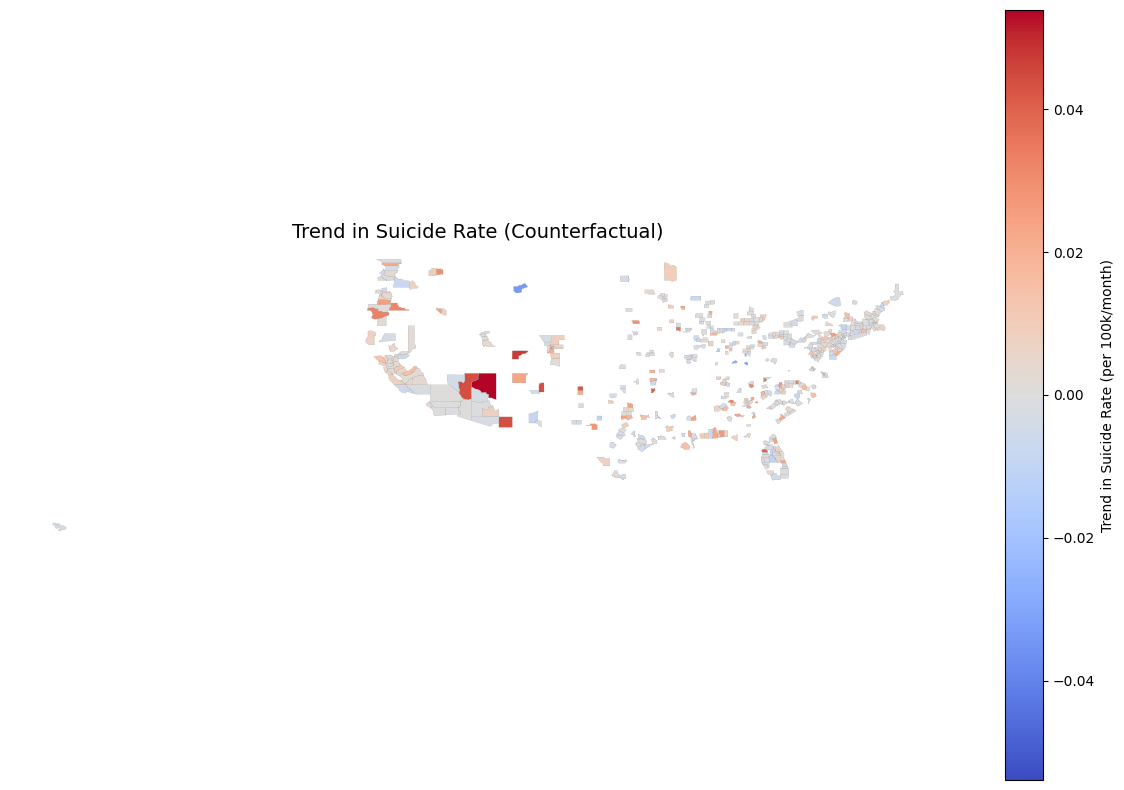

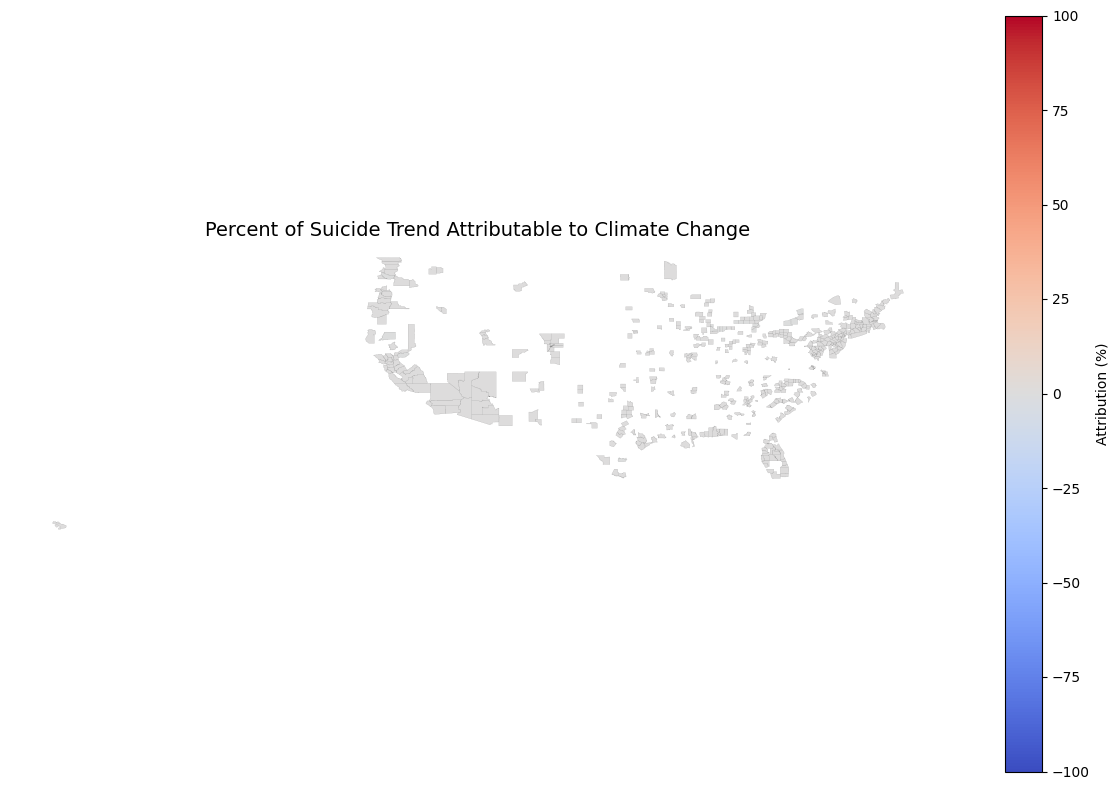

In [ ]:
plot_county_map(full_coverage, 'actual_trend',
                title='Trend in Suicide Rate (Actual)',
                legend_title='Trend in Suicide Rate (per 100k/month)')

plot_county_map(full_coverage, 'cf_trend',
                title='Trend in Suicide Rate (Counterfactual)',
                legend_title='Trend in Suicide Rate (per 100k/month)')


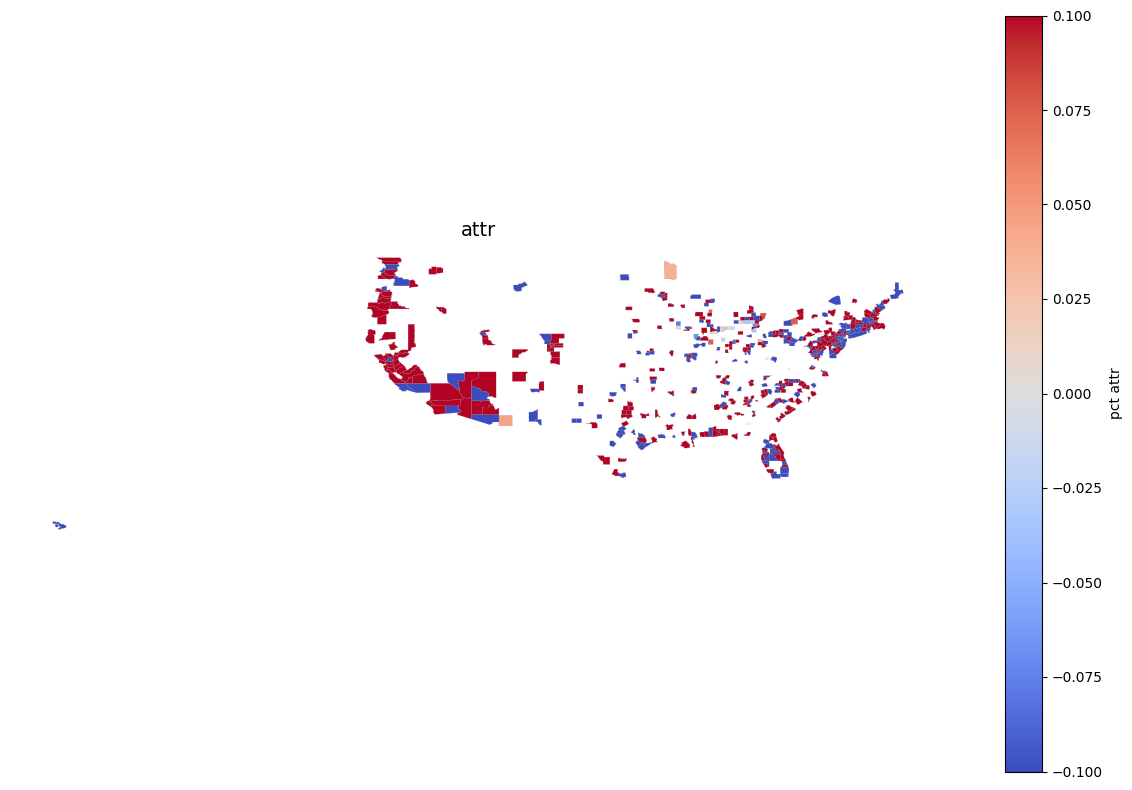

In [45]:
plot_county_map(full_coverage, 'pct_attributable_climate',
                title='attr',
                legend_title='pct attr')

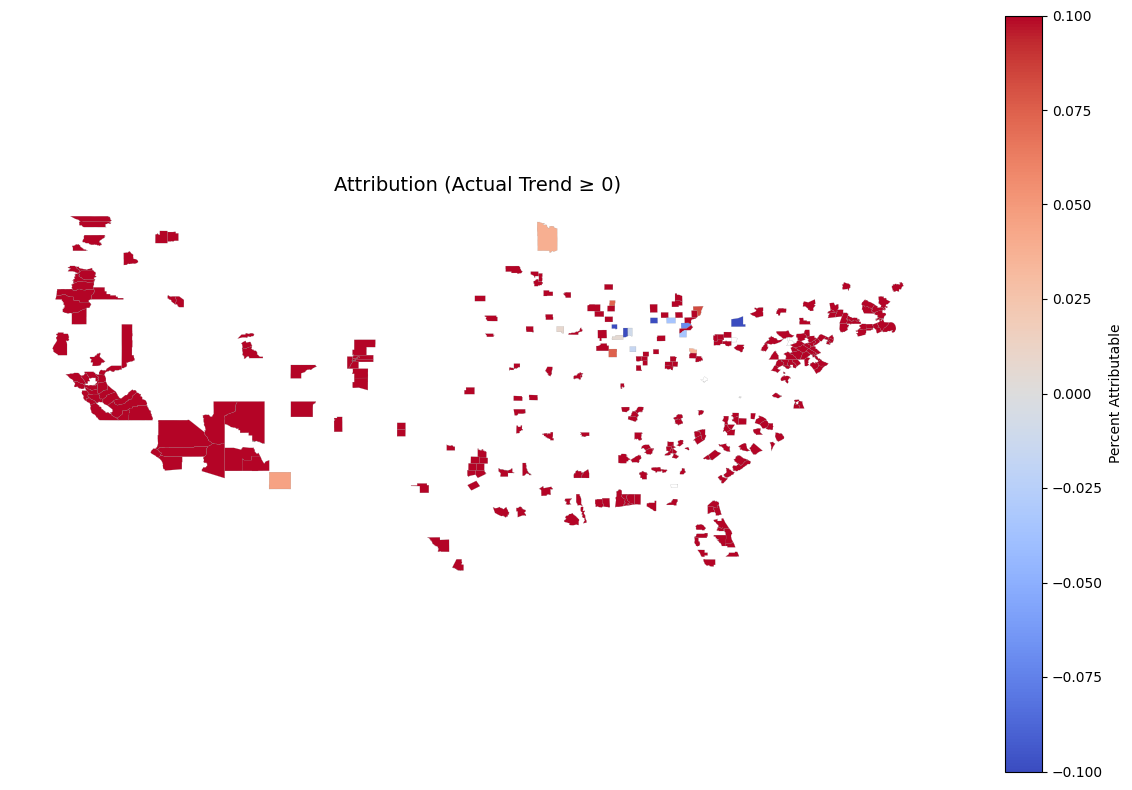

In [51]:
plot_county_map(
    full_coverage[full_coverage['actual_trend'] >= 0],
    column='pct_attributable_climate',
    title='Attribution (Actual Trend ≥ 0)',
    legend_title='Percent Attributable'
)


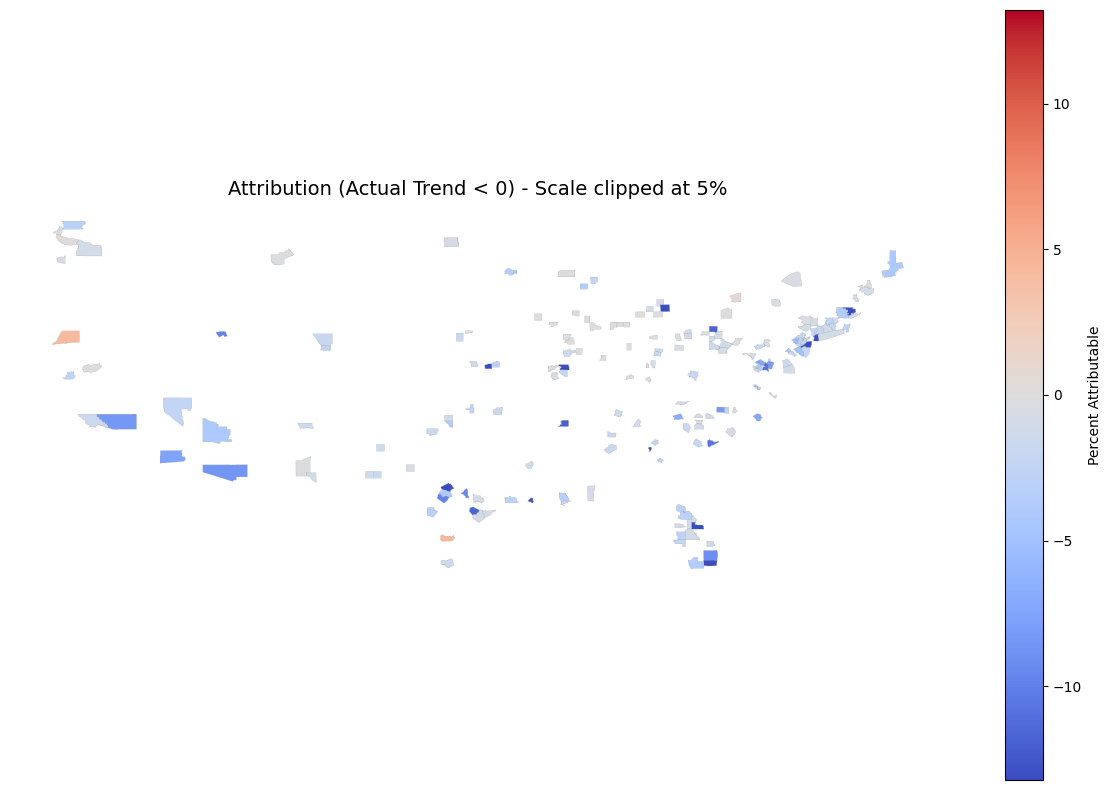

In [64]:
plot_county_map(
    full_coverage[full_coverage['actual_trend'] < 0],
    column='pct_attributable_climate',
    title='Attribution (Actual Trend < 0) - Scale clipped at 5%',
    legend_title='Percent Attributable',
    clip_pct = 5
)


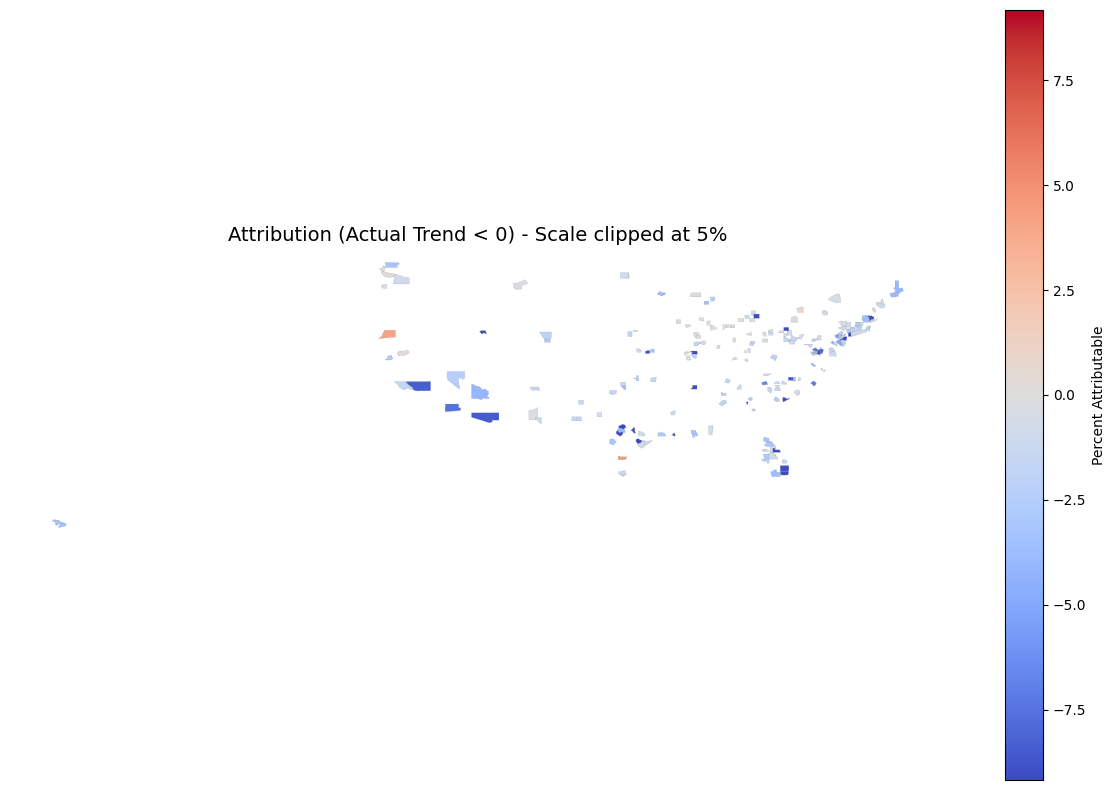

In [58]:
plot_county_map(
    full_coverage[full_coverage['actual_trend'] < 0],
    column='pct_attributable_climate',
    title='Attribution (Actual Trend < 0) - Scale clipped at 5%',
    legend_title='Percent Attributable',
    clip_pct = 10
)


/tmp/ipykernel_3227438/1464799647.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('bin')


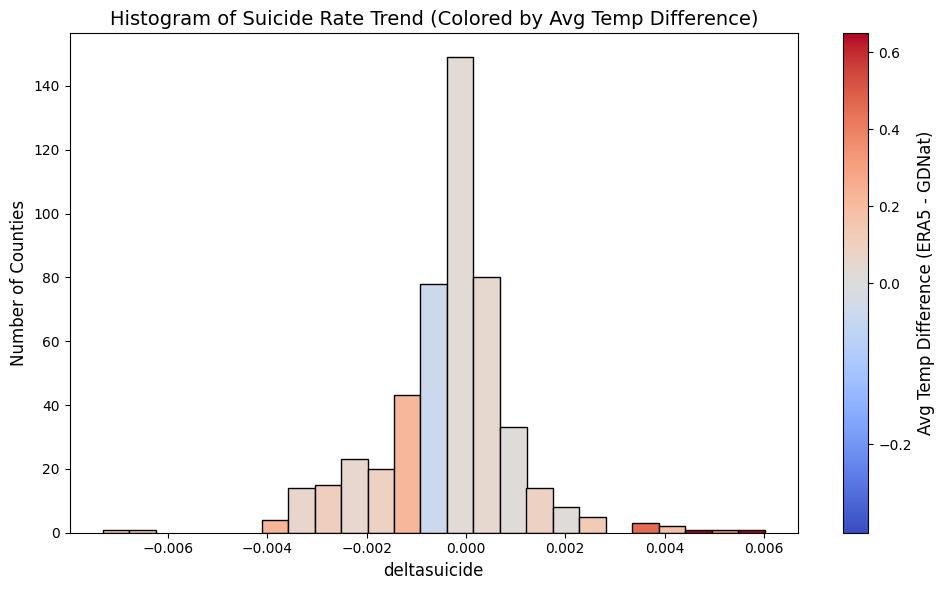

In [36]:
# Create bins for deltasuicide
bins = np.linspace(full_coverage_merged['deltasuicide'].min(), full_coverage_merged['deltasuicide'].max(), 30)
full_coverage_merged['bin'] = pd.cut(full_coverage_merged['deltasuicide'], bins)

# Group by bin to count and average temp diff
hist_data = (
    full_coverage_merged
    .groupby('bin')
    .agg(
        count=('deltasuicide', 'count'),
        mean_temp_diff=('diff_temp', 'mean')
    )
    .dropna()
    .reset_index()
)

# Bin centers and bar width
bin_centers = [b.mid for b in hist_data['bin']]
bar_width = np.diff(bins)[0]

# Normalize temp diff for color mapping

# Compute 1st and 99th percentiles of diff_temp
vmin = full_coverage_merged['diff_temp'].quantile(0.05)
vmax = full_coverage_merged['diff_temp'].quantile(0.95)

# Create a diverging norm centered at zero
norm = TwoSlopeNorm(vcenter=0, vmin=vmin, vmax=vmax)
colors = [coolwarm(norm(val)) for val in hist_data['mean_temp_diff']]

# Plot colored histogram
fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(bin_centers, hist_data['count'], width=bar_width, color=colors, edgecolor='black')

# Add colorbar
sm = plt.cm.ScalarMappable(cmap=coolwarm, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label("Avg Temp Difference (ERA5 - GDNat)", fontsize=12)

# Final formatting
ax.set_title("Histogram of Suicide Rate Trend (Colored by Avg Temp Difference)", fontsize=14)
ax.set_xlabel("deltasuicide", fontsize=12)
ax.set_ylabel("Number of Counties", fontsize=12)

plt.tight_layout()
plt.show()


In [37]:
attribution_output_data

,year,month,order_1_avg.x,date.x,y_hat_era5,poly_id,y_hat_gdnat,NAME,NAMELSAD,ID_1,ID_2,date.y,order_1_avg.y,diff_suicide,diff_temp
0,1980,1,9.528785,1980-01-01,0.132186,1001,0.132119,Autauga,Autauga County,1.0,1.0,1980-01-01,9.979710,0.000068,-0.450925
1,1980,2,7.258004,1980-02-01,0.097429,1001,0.096176,Autauga,Autauga County,1.0,1.0,1980-02-01,7.288643,0.001253,-0.030640
2,1980,3,12.688986,1980-03-01,0.140456,1001,0.147207,Autauga,Autauga County,1.0,1.0,1980-03-01,13.357411,-0.006752,-0.668425
3,1980,4,16.842135,1980-04-01,0.160386,1001,0.164409,Autauga,Autauga County,1.0,1.0,1980-04-01,17.411411,-0.004022,-0.569276
4,1980,5,22.053573,1980-05-01,0.168159,1001,0.168080,Autauga,Autauga County,1.0,1.0,1980-05-01,22.256600,0.000079,-0.203027
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
968395,2004,8,27.617651,2004-08-01,0.331925,78030,0.323857,St. Thomas,St. Thomas Island,78.0,30.0,2004-08-01,27.220027,0.008068,0.397624
968396,2004,9,27.267894,2004-09-01,0.336256,78030,0.325469,St. Thomas,St. Thomas Island,78.0,30.0,2004-09-01,26.725004,0.010787,0.542890
968397,2004,10,26.952252,2004-10-01,0.332331,78030,0.322878,St. Thomas,St. Thomas Island,78.0,30.0,2004-10-01,26.390567,0.009453,0.561685
968398,2004,11,26.055954,2004-11-01,0.320676,78030,0.310561,St. Thomas,St. Thomas Island,78.0,30.0,2004-11-01,25.428801,0.010116,0.627152


## NA Checks 

In [ ]:
# Convert fips to 5-digit string format (same as used in the merge)
slopes['fips_str'] = slopes['fips'].astype(int).astype(str).str.zfill(5)

# Get unique GEOIDs in the shapefile
geoid_set = set(usa_counties['GEOID'].unique())

# Check which slopes fips_str are not in the shapefile
unmatched_from_slopes = slopes[~slopes['fips_str'].isin(geoid_set)]

# Print results
if unmatched_from_slopes.empty:
    print("✅ All counties in the suicide data matched with the shapefile.")
else:
    print(f"❌ {len(unmatched_from_slopes)} counties from the suicide data did NOT match the shapefile:")
    print(unmatched_from_slopes[['fips', 'fips_str']])


# I county (fips 12025) doesn't match... this must be explored 


❌ 1 counties from the suicide data did NOT match the shapefile:
        fips fips_str
301  12025.0    12025


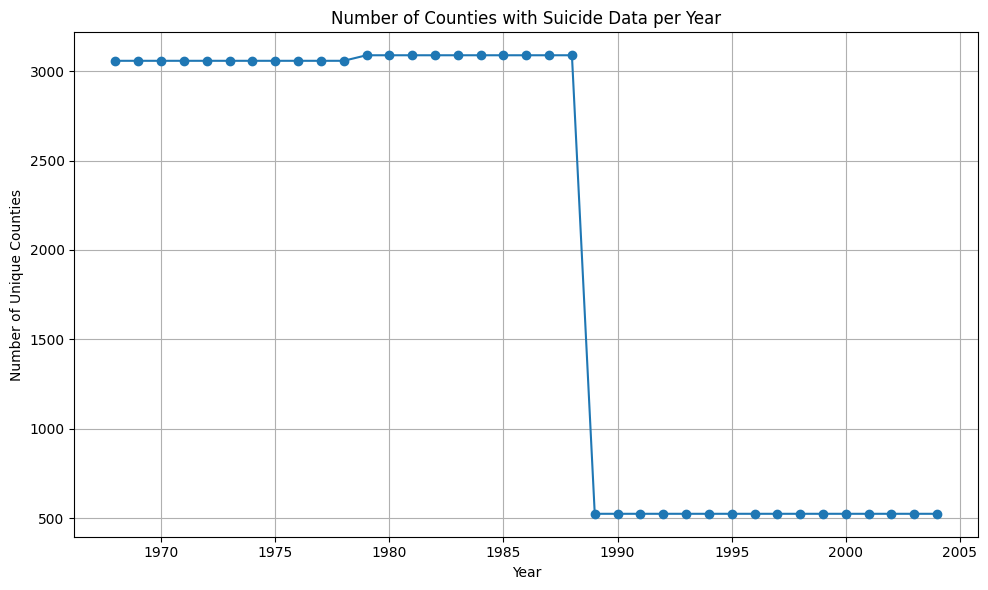

In [13]:
# Count unique counties per year
county_counts_by_year = (
    filtered_suicide
    .dropna(subset=['suiciderate'])  # Optional: drop rows with missing suicide rate
    .groupby('year')['fips']
    .nunique()
    .reset_index(name='num_counties')
)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(county_counts_by_year['year'], county_counts_by_year['num_counties'], marker='o')
plt.title("Number of Counties with Suicide Data per Year")
plt.xlabel("Year")
plt.ylabel("Number of Unique Counties")
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd

# Drop rows with missing suiciderate
filtered_nonmissing = filtered_suicide.dropna(subset=['suiciderate'])

# Count unique counties per year
county_counts_by_year = (
    filtered_nonmissing
    .groupby('year')['fips']
    .nunique()
    .reset_index(name='num_counties')
)

# Split into periods
pre_1978 = county_counts_by_year[county_counts_by_year['year'] < 1979]
period_1978_1988 = county_counts_by_year[(county_counts_by_year['year'] >= 1979) & (county_counts_by_year['year'] < 1989)]
post_1989 = county_counts_by_year[county_counts_by_year['year'] >= 1989]

# Helper function
def stable_count(df):
    counts = df['num_counties'].unique()
    return counts[0] if len(counts) == 1 else -1

# Summary table
summary_table = pd.DataFrame({
    'period': ['Pre-1978', '1978–1988', '1989+'],
    'num_unique_counties': [
        stable_count(pre_1978),
        stable_count(period_1978_1988),
        stable_count(post_1989)
    ]
})

print(summary_table)


      period  num_unique_counties
0   Pre-1978                 3058
1  1978–1988                 3089
2      1989+                  524


In [18]:
# Filter to 1979 and later
filtered_1979plus = filtered_suicide[
    (filtered_suicide['year'] >= 1979) & 
    (~filtered_suicide['suiciderate'].isna())
]

# Get unique fips codes for each period
fips_1979_1988 = set(
    filtered_1979plus[(filtered_1979plus['year'] <= 1988)]['fips'].unique()
)
fips_1989plus = set(
    filtered_1979plus[(filtered_1979plus['year'] >= 1989)]['fips'].unique()
)

# 1. Counties with data for BOTH periods
counties_all_periods = fips_1979_1988 & fips_1989plus
print(f"✅ Counties with data for BOTH periods: {len(counties_all_periods)}")

# 2. Counties with data ONLY in 1979–1988
counties_only_1979_1988 = fips_1979_1988 - fips_1989plus
print(f"✅ Counties with data ONLY in 1979–1988: {len(counties_only_1979_1988)}")


✅ Counties with data for BOTH periods: 523
✅ Counties with data ONLY in 1979–1988: 2566


# Archive

## Diagnostics

In [ ]:

# NA summary on merged dasta
# Step 1: Group by county and find missing counts
missing_summary = subset.groupby('fips').apply(
    lambda g: pd.Series({
        'n_missing_actual': g['suiciderate'].isna().sum(),
        'n_missing_cf': g['suiciderate_cf'].isna().sum()
    })
).reset_index()

# Identify counties with any missing data
counties_with_nas = missing_summary[
    (missing_summary['n_missing_actual'] > 0) | (missing_summary['n_missing_cf'] > 0)
]

# Print summary
print(f"Number of counties with any NaNs: {len(counties_with_nas)}")
print(f"Average # of missing months (actual): {counties_with_nas['n_missing_actual'].mean():.2f}")
print(f"Average # of missing months (cf): {counties_with_nas['n_missing_cf'].mean():.2f}")


Number of unique counties in merged dataset: 522


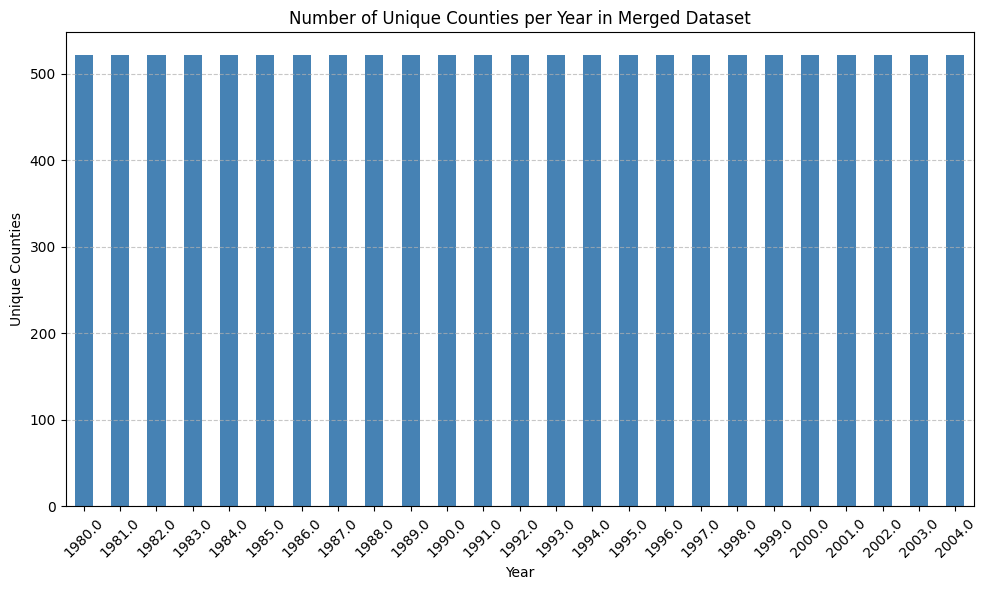

In [ ]:
# diagnostics on merge

# Count matches
n_matched = len(merged)
n_suicide = len(complete_data_suicide)
n_attr = len(attribution_output_data)

unique_counties = merged['fips'].nunique()
print(f"Number of unique counties in merged dataset: {unique_counties}")

# Group by year and count unique counties
county_counts_per_year = merged.groupby('year')['fips'].nunique()

# Plot
plt.figure(figsize=(10, 6))
county_counts_per_year.plot(kind='bar', color='steelblue')

plt.title("Number of Unique Counties per Year in Merged Dataset")
plt.xlabel("Year")
plt.ylabel("Unique Counties")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()